In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyspark.sql.functions as f
import statsmodels.api as sm
from gentropy.common.session import Session


Loading BokehJS ...

/Users/dc16/Gentropy-manuscript/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.



In [2]:
session = Session(extended_spark_conf={"spark.driver.memory": "10g"})
release_path = "../../../data/25.06/output/"
output_path = "../../../data/intermediate_files/"


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/14 12:05:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


# Loading inputs


In [3]:
geneConcordance = (
    session.spark.read.parquet(f"{output_path}variants_pleiotropy")
    .withColumn(
        "betaSignConcordance", f.when(f.col("betaSignConcordance").isNull(), 1).otherwise(f.col("betaSignConcordance"))
    )
    .select("variantId", "betaSignConcordance", f.explode("prioritisedGenes").alias("geneId"))
    .groupBy("geneId")
    .agg(
        f.min("betaSignConcordance").alias("betaSignConcordanceMin"),
        f.mean("betaSignConcordance").alias("betaSignConcordanceMean"),
        f.max("betaSignConcordance").alias("betaSignConcordanceMax"),
        f.count("*").alias("numVariants"),
    )
)


In [4]:
genePS = session.spark.read.parquet(f"{output_path}genes_pleiotropy").select(
    "geneId", "approvedSymbol", "uniqueDiseases", "uniqueTherapeuticAreas"
)


In [5]:
safetyEvents = (
    session.spark.read.parquet(f"{release_path}target_prioritisation")
    .select(f.col("targetId").alias("geneId"), "hasSafetyEvent")
    .withColumn("hasSafetyEvent", f.when(f.col("hasSafetyEvent") == "-1", 1).otherwise(0))
)


In [6]:
df = genePS.join(geneConcordance, on="geneId", how="left").join(safetyEvents, on="geneId", how="left")
df.count()


8285

In [7]:
(df.show())


+---------------+--------------+--------------+----------------------+----------------------+-----------------------+----------------------+-----------+--------------+
|         geneId|approvedSymbol|uniqueDiseases|uniqueTherapeuticAreas|betaSignConcordanceMin|betaSignConcordanceMean|betaSignConcordanceMax|numVariants|hasSafetyEvent|
+---------------+--------------+--------------+----------------------+----------------------+-----------------------+----------------------+-----------+--------------+
|ENSG00000001084|          GCLC|             2|                     1|                   1.0|                    1.0|                   1.0|          2|             1|
|ENSG00000002016|         RAD52|             2|                     1|                   1.0|                    1.0|                   1.0|          2|             1|
|ENSG00000002726|          AOC1|             6|                     4|                   0.5|     0.9285714285714286|                   1.0|          7|        

# Target safety events vs pleiotropy logistic regression


Univariate logistic regression results:
                  covariate  coefficient  std_error       p_value  ci_lower  \
0            uniqueDiseases     0.322051   0.031213  5.850551e-25  0.260875   
1       betaSignDiscordance     0.280724   0.032736  9.872881e-18  0.216563   
2  pleiotropy_x_discordance     0.080552   0.011754  7.210153e-12  0.057516   

   ci_upper  
0  0.383227  
1  0.344885  
2  0.103589  

Multivariate logistic regression results:
                  covariate  coefficient  std_error       p_value  ci_lower  \
0            uniqueDiseases     0.418176   0.051840  7.227544e-16  0.316571   
1       betaSignDiscordance     0.179901   0.039958  6.723347e-06  0.101585   
2  pleiotropy_x_discordance    -0.079234   0.019356  4.249898e-05 -0.117171   

   ci_upper  
0  0.519781  
1  0.258217  
2 -0.041296  

Pseudo R-squared: 0.0317
Safety events: 570 / 8285 genes (6.9%)


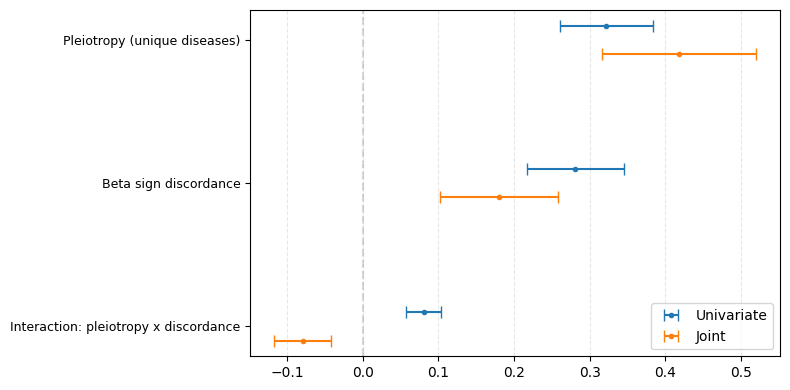

In [8]:
# Convert to pandas and prepare data
df_pd = df.toPandas().dropna(subset=["hasSafetyEvent"]).copy()

# Create discordance measure (1 - concordance)
df_pd["betaSignDiscordance"] = 1 - df_pd["betaSignConcordanceMin"].fillna(1.0)

# Standardize covariates
for col in ["uniqueDiseases", "betaSignDiscordance"]:
    df_pd[col] = (df_pd[col] - df_pd[col].mean()) / df_pd[col].std()

# Interaction term: pleiotropy * discordance
df_pd["pleiotropy_x_discordance"] = df_pd["uniqueDiseases"] * df_pd["betaSignDiscordance"]

# Include interaction in both univariate and joint models
covariates = ["uniqueDiseases", "betaSignDiscordance", "pleiotropy_x_discordance"]

# Univariate logistic regression
univariate_results = []
for covariate in covariates:
    x_uni = sm.add_constant(df_pd[[covariate]])
    y_uni = df_pd["hasSafetyEvent"]
    model_uni = sm.Logit(y_uni, x_uni).fit(disp=False)
    coef = model_uni.params[covariate]
    se = model_uni.bse[covariate]
    pvalue = model_uni.pvalues[covariate]
    ci_lower = model_uni.conf_int().loc[covariate, 0]
    ci_upper = model_uni.conf_int().loc[covariate, 1]
    univariate_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
results_df = pd.DataFrame(univariate_results)

# Multivariate logistic regression
x_multi = sm.add_constant(df_pd[covariates])
y_multi = df_pd["hasSafetyEvent"]
model_multi = sm.Logit(y_multi, x_multi).fit(disp=False)

multi_results = []
for covariate in covariates:
    coef = model_multi.params[covariate]
    se = model_multi.bse[covariate]
    pvalue = model_multi.pvalues[covariate]
    ci_lower = model_multi.conf_int().loc[covariate, 0]
    ci_upper = model_multi.conf_int().loc[covariate, 1]
    multi_results.append(
        {
            "covariate": covariate,
            "coefficient": coef,
            "std_error": se,
            "p_value": pvalue,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        }
    )
multi_df = pd.DataFrame(multi_results)

print("Univariate logistic regression results:")
print(results_df)
print("\nMultivariate logistic regression results:")
print(multi_df)
print(f"\nPseudo R-squared: {model_multi.prsquared:.4f}")
print(
    f"Safety events: {int(df_pd['hasSafetyEvent'].sum())} / {len(df_pd)} genes ({df_pd['hasSafetyEvent'].mean():.1%})"
)

# Combine for plotting
results_df["model_type"] = "Univariate"
multi_df["model_type"] = "Joint"
combined_results = pd.concat([results_df, multi_df], ignore_index=True)

covariate_order = covariates
y_mapping = {cov: i for i, cov in enumerate(covariate_order)}
combined_results["y_numerical"] = combined_results["covariate"].map(y_mapping)

offset_val = 0.1
combined_results["y_plot"] = combined_results["y_numerical"] + np.where(
    combined_results["model_type"] == "Univariate", -offset_val, offset_val
)

# Forest plot
fig, ax = plt.subplots(figsize=(8, 4))

univariate_data = combined_results[combined_results["model_type"] == "Univariate"]
xerr_uni = [
    univariate_data["coefficient"] - univariate_data["ci_lower"],
    univariate_data["ci_upper"] - univariate_data["coefficient"],
]
ax.errorbar(
    x=univariate_data["coefficient"],
    y=univariate_data["y_plot"],
    xerr=xerr_uni,
    fmt="o",
    label="Univariate",
    capsize=4,
    markersize=3,
)

multi_data = combined_results[combined_results["model_type"] == "Joint"]
xerr_multi = [
    multi_data["coefficient"] - multi_data["ci_lower"],
    multi_data["ci_upper"] - multi_data["coefficient"],
]
ax.errorbar(
    x=multi_data["coefficient"],
    y=multi_data["y_plot"],
    xerr=xerr_multi,
    fmt="o",
    label="Joint",
    capsize=4,
    markersize=3,
)

ax.axvline(x=0, color="gray", linestyle="--", alpha=0.3)
label_map = {
    "uniqueDiseases": "Pleiotropy (unique diseases)",
    "betaSignDiscordance": "Beta sign discordance",
    "pleiotropy_x_discordance": "Interaction: pleiotropy x discordance",
}
ax.set_yticks([y_mapping[cov] for cov in covariate_order])
ax.set_yticklabels([label_map[cov] for cov in covariate_order], fontsize=9)
ax.invert_yaxis()
ax.legend()

plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
df_pd[covariates].corr()


,uniqueDiseases,betaSignDiscordance,pleiotropy_x_discordance
uniqueDiseases,1.000000,0.492034,0.781137
betaSignDiscordance,0.492034,1.000000,0.519646
pleiotropy_x_discordance,0.781137,0.519646,1.000000
